# Customer behavior on Instacart: funnel, retention and a simulated A/B test

This notebook walks through the results written by `make sql` and `make ab`. Every number comes from the CSV files in `reports/tables/`, which the SQL files and `src/ab_test.py` produce. The one thing that is not real data is the A/B test, which is simulated and labelled as such.

The dataset has no calendar dates. Time is measured from each user's own first order, using the running sum of `days_since_prior_order`, which is capped at 30.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent
T = ROOT / "reports" / "tables"
pd.options.display.float_format = "{:.4f}".format

## 1. Data checks

In [2]:
v = pd.read_csv(ROOT / "docs" / "validation.csv")
print(v.status.value_counts().to_string())
v[v.status == "INFO"]

status
PASS    26
INFO    12


,check_name,observed,expected,status
0,rows: orders,3421083,NaN,INFO
1,rows: order_products__prior,32434489,NaN,INFO
2,rows: order_products__train,1384617,NaN,INFO
3,rows: products,49688,NaN,INFO
4,rows: aisles,134,NaN,INFO
5,rows: departments,21,NaN,INFO
22,orders with eval_set=test (no line items by de...,75000,NaN,INFO
33,users,206209,NaN,INFO
34,min orders per user,4,NaN,INFO
35,max orders per user,100,NaN,INFO


All pass/fail checks pass. Two facts from the INFO rows shape everything after: every user has between 4 and 100 orders, and about 10.8% of orders carry the capped gap of 30 days.

## 2. Funnel

,order_k,users_reaching,total_users,share_of_users,share_of_previous_step
0,1,206209.0000,206209,1.0000,NaN
1,2,206209.0000,206209,1.0000,1.0000
2,3,206209.0000,206209,1.0000,1.0000
3,5,182223.0000,206209,0.8837,0.8837
4,10,110728.0000,206209,0.5370,0.6077


,order_k,users,p25_days_since_first,median_days_since_first,p75_days_since_first
0,2,206209,7.0000,13.0000,28.0000
1,3,206209,15.0000,29.0000,44.0000
2,5,182223,34.0000,57.0000,81.0000
3,10,110728,70.0000,106.0000,148.0000


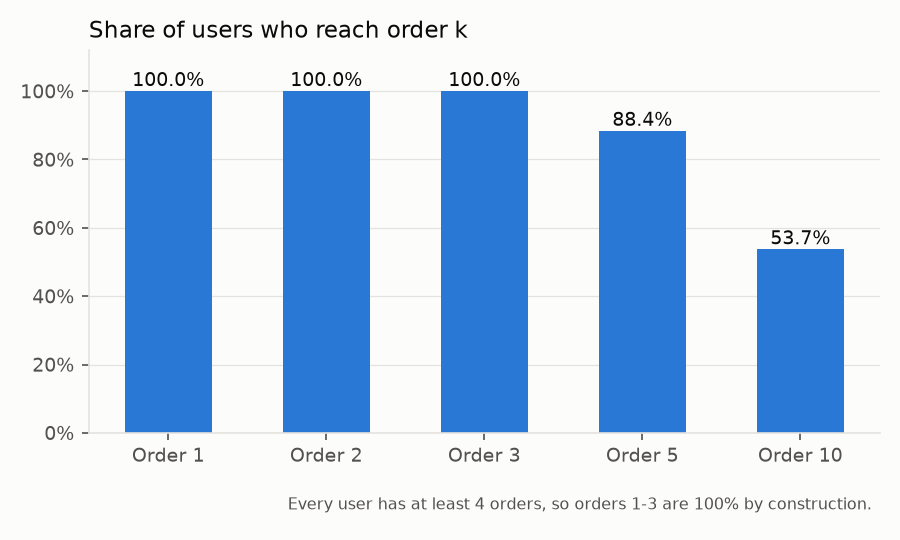

In [3]:
display(pd.read_csv(T / "funnel.csv"))
display(pd.read_csv(T / "funnel_timing.csv"))
Image(ROOT / "reports" / "funnel.png")

Reaching orders 2 and 3 is 100% because the sample only contains users with at least 4 orders. The informative steps are order 5 (88.4% of users) and order 10 (53.7%). The median user places order 10 about 106 days after their first, and that is a lower bound because of the cap.

## 3. Retention

,segment_type,segment,users,retained_7d,retained_14d,retained_30d_lower,share_second_gap_capped,meets_min_users
0,all,all,206209,0.3258,0.5575,0.7680,0.2320,True
1,first_basket_size,1-5 items,63775,0.3186,0.5293,0.7436,0.2564,True
2,first_basket_size,11-20 items,59749,0.3244,0.5704,0.7818,0.2182,True
3,first_basket_size,21+ items,19148,0.3041,0.5620,0.7789,0.2211,True
4,first_basket_size,6-10 items,63537,0.3407,0.5722,0.7762,0.2238,True


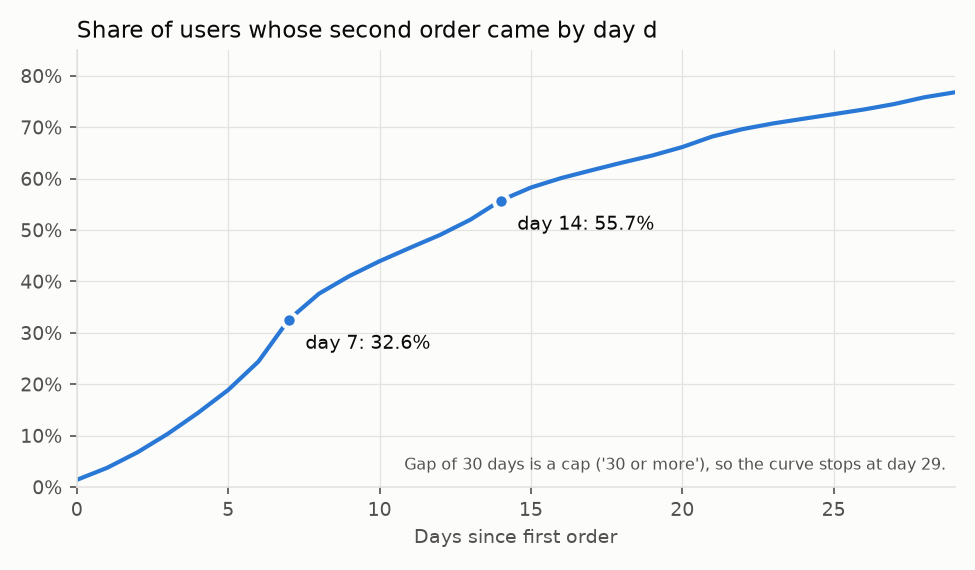

In [4]:
r = pd.read_csv(T / "retention_by_segment.csv")
display(r[r.segment_type.isin(["all", "first_basket_size"])])
Image(ROOT / "reports" / "return_curve.png")

32.6% of users place a second order within 7 days and 55.7% within 14 days. At least 76.8% do so within 30 days; the remaining 23.2% have a second gap recorded as 30, meaning 30 or more days. The return curve climbs steeply into day 7 (24.4% at day 6, 32.6% at day 7), which looks like a weekly shopping habit. This is a pattern in the data, not a tested cause.

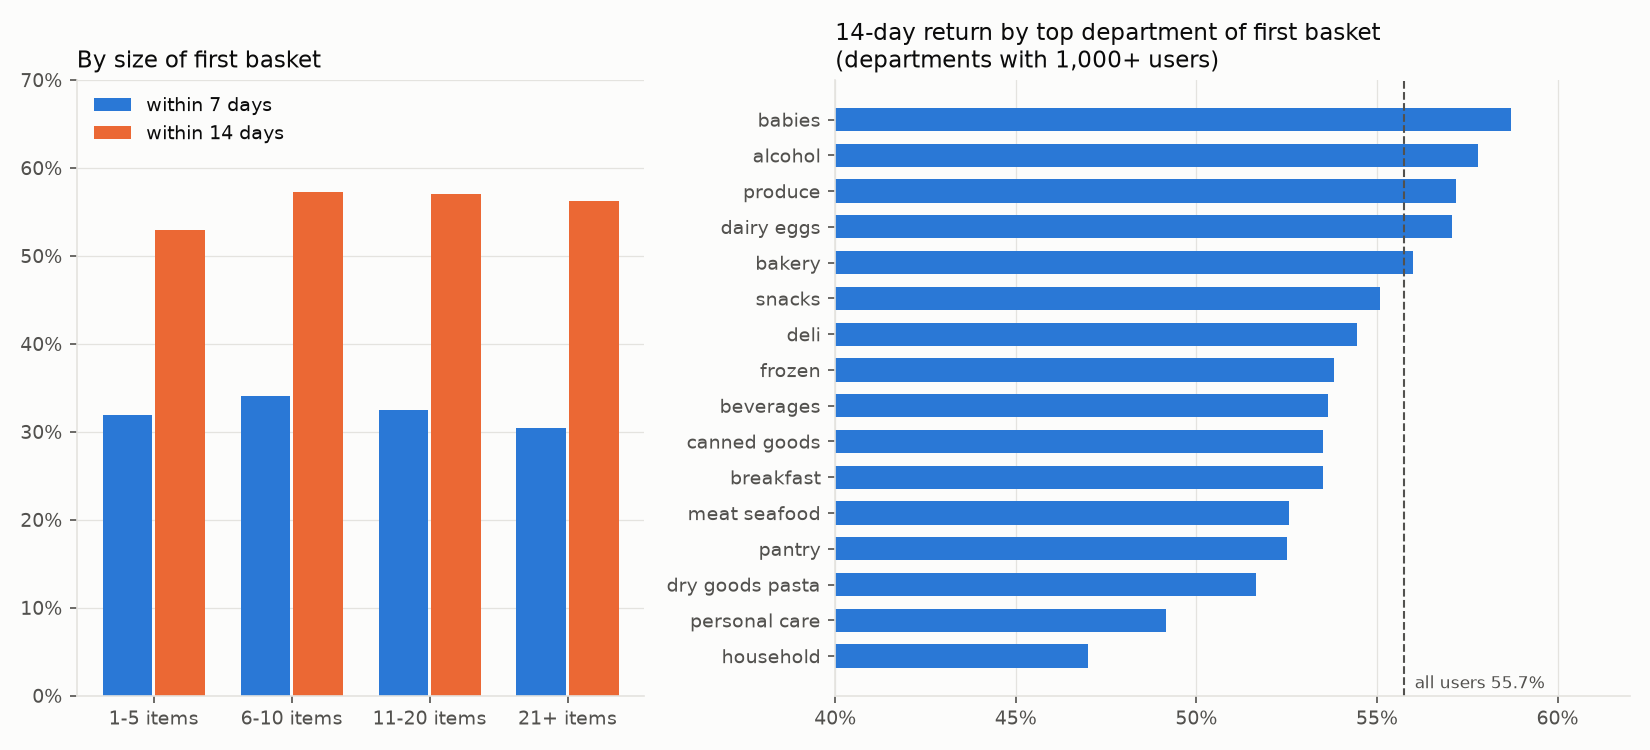

In [5]:
Image(ROOT / "reports" / "retention_by_segment.png")

Users whose first basket has 1-5 items return least (52.9% within 14 days, against 57.2% for 6-10 items). By department, users whose first basket is mostly household or personal care items return least (47.0% and 49.2% within 14 days) and babies and alcohol most. Small groups are excluded from the department chart and flagged in the table. These are associations between the first basket and return timing, not effects of the products.

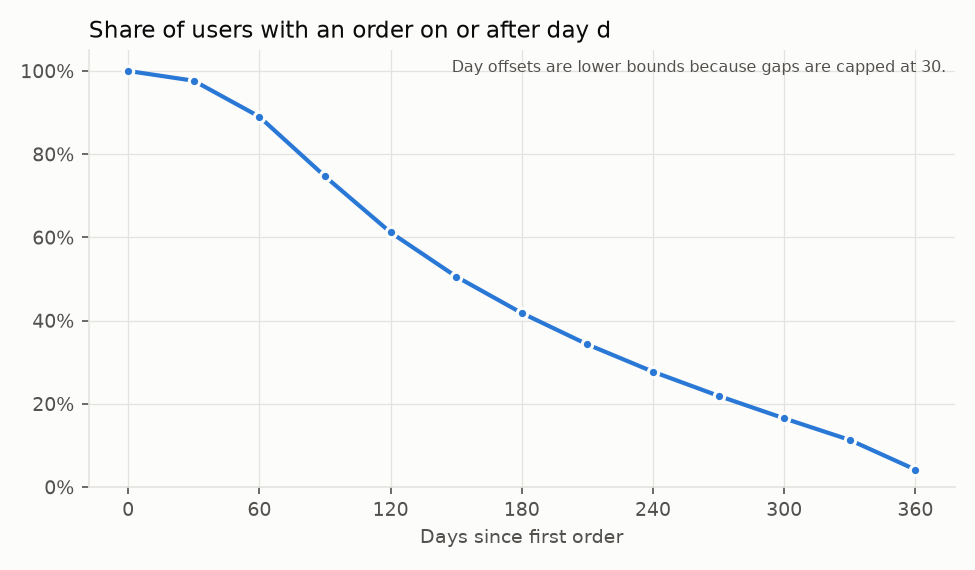

In [6]:
Image(ROOT / "reports" / "activity_curve.png")

## 4. Reorder rate by category

,department,line_items,reorder_rate,meets_min_support
0,dairy eggs,5298037,0.7123,True
1,beverages,2636557,0.6952,True
2,produce,9303994,0.6914,True
3,bakery,1149640,0.6697,True
4,deli,1025441,0.6497,True
5,pets,95598,0.6443,True
6,alcohol,146580,0.6208,True
7,snacks,2825503,0.6112,True
8,babies,416256,0.6089,True
9,meat seafood,691871,0.6076,True


,department,aisle,line_items,reorder_rate,meets_min_support
0,dairy eggs,milk,873300,0.8269,True
1,beverages,water seltzer sparkling water,828737,0.7735,True
2,produce,fresh fruits,3576770,0.7622,True
3,dairy eggs,eggs,443708,0.7514,True
4,produce,packaged produce,271366,0.7382,True


,department,aisle,line_items,reorder_rate,meets_min_support
126,personal care,skin care,10132,0.2564,True
127,personal care,cold flu allergy,25588,0.2521,True
130,personal care,first aid,10536,0.2121,True
132,pantry,baking supplies decor,23070,0.1801,True
133,pantry,spices seasonings,206247,0.1641,True


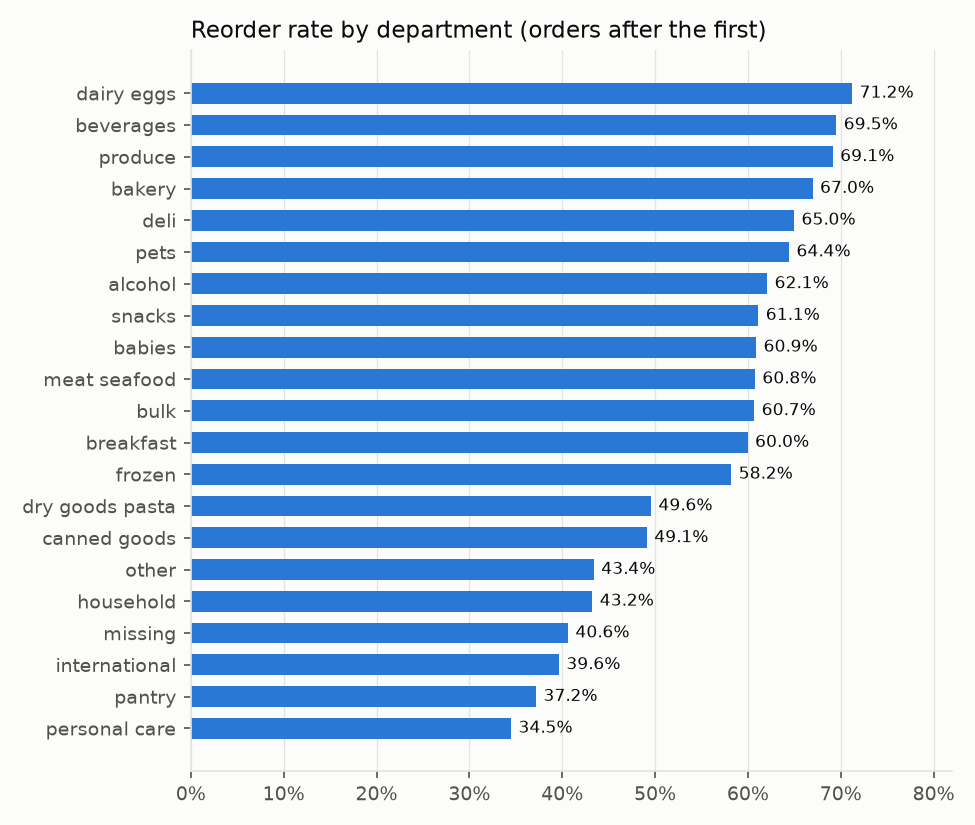

In [7]:
d = pd.read_csv(T / "reorder_by_department.csv")
display(d)
a = pd.read_csv(T / "reorder_by_aisle.csv")
display(a[a.meets_min_support].head(5))
display(a[a.meets_min_support].tail(5))
Image(ROOT / "reports" / "reorder_by_department.png")

Dairy eggs, beverages and produce are bought again most often (about 69-71% of line items after the first order). Pantry and personal care are lowest (37% and 34%). Milk is the highest aisle (82.7%) and spices and seasonings the lowest (16.4%). First orders are excluded from the rate because they cannot contain reorders. Six aisles fall below the 10,000 line-item support threshold and are flagged in the table.

## 5. Basket affinity

,product_a_name,product_b_name,pair_orders,lift
0,Bag of Organic Bananas,Organic Hass Avocado,64761,2.4842
1,Bag of Organic Bananas,Organic Strawberries,64702,1.9893
2,Organic Strawberries,Banana,58330,1.4416
3,Banana,Organic Avocado,55611,2.0559
4,Organic Baby Spinach,Banana,53395,1.4448
5,Bag of Organic Bananas,Organic Baby Spinach,52608,1.7708
6,Strawberries,Banana,43180,1.9679
7,Banana,Large Lemon,43038,1.8230
8,Organic Strawberries,Organic Hass Avocado,42333,2.3271
9,Bag of Organic Bananas,Organic Raspberries,42283,2.5122


,product_a_name,product_b_name,pair_orders,lift
0,Total 2% Lowfat Greek Strained Yogurt With Blu...,Total 2% Lowfat Greek Strained Yogurt with Peach,6461,49.1436
1,Total 2% Lowfat Greek Strained Yogurt With Blu...,Total 2% with Strawberry Lowfat Greek Strained...,9565,48.4425
2,Total 2% with Strawberry Lowfat Greek Strained...,Total 2% Lowfat Greek Strained Yogurt with Peach,8241,43.4693
3,Total 2% All Natural Greek Strained Yogurt wit...,Total 2% with Strawberry Lowfat Greek Strained...,5947,27.0380
4,Total 2% Lowfat Greek Strained Yogurt With Blu...,Total 2% All Natural Greek Strained Yogurt wit...,4019,26.3488
5,Total 2% All Natural Greek Strained Yogurt wit...,Total 2% Lowfat Greek Strained Yogurt with Peach,3816,26.0562
6,Frozen Organic Wild Blueberries,Organic Whole Strawberries,7015,23.2078
7,Yellow Bell Pepper,Orange Bell Pepper,7520,23.0213
8,Sparkling Lemon Water,Lime Sparkling Water,8874,17.8913
9,Sparkling Lemon Water,Peach Pear Flavored Sparkling Water,3374,14.9106


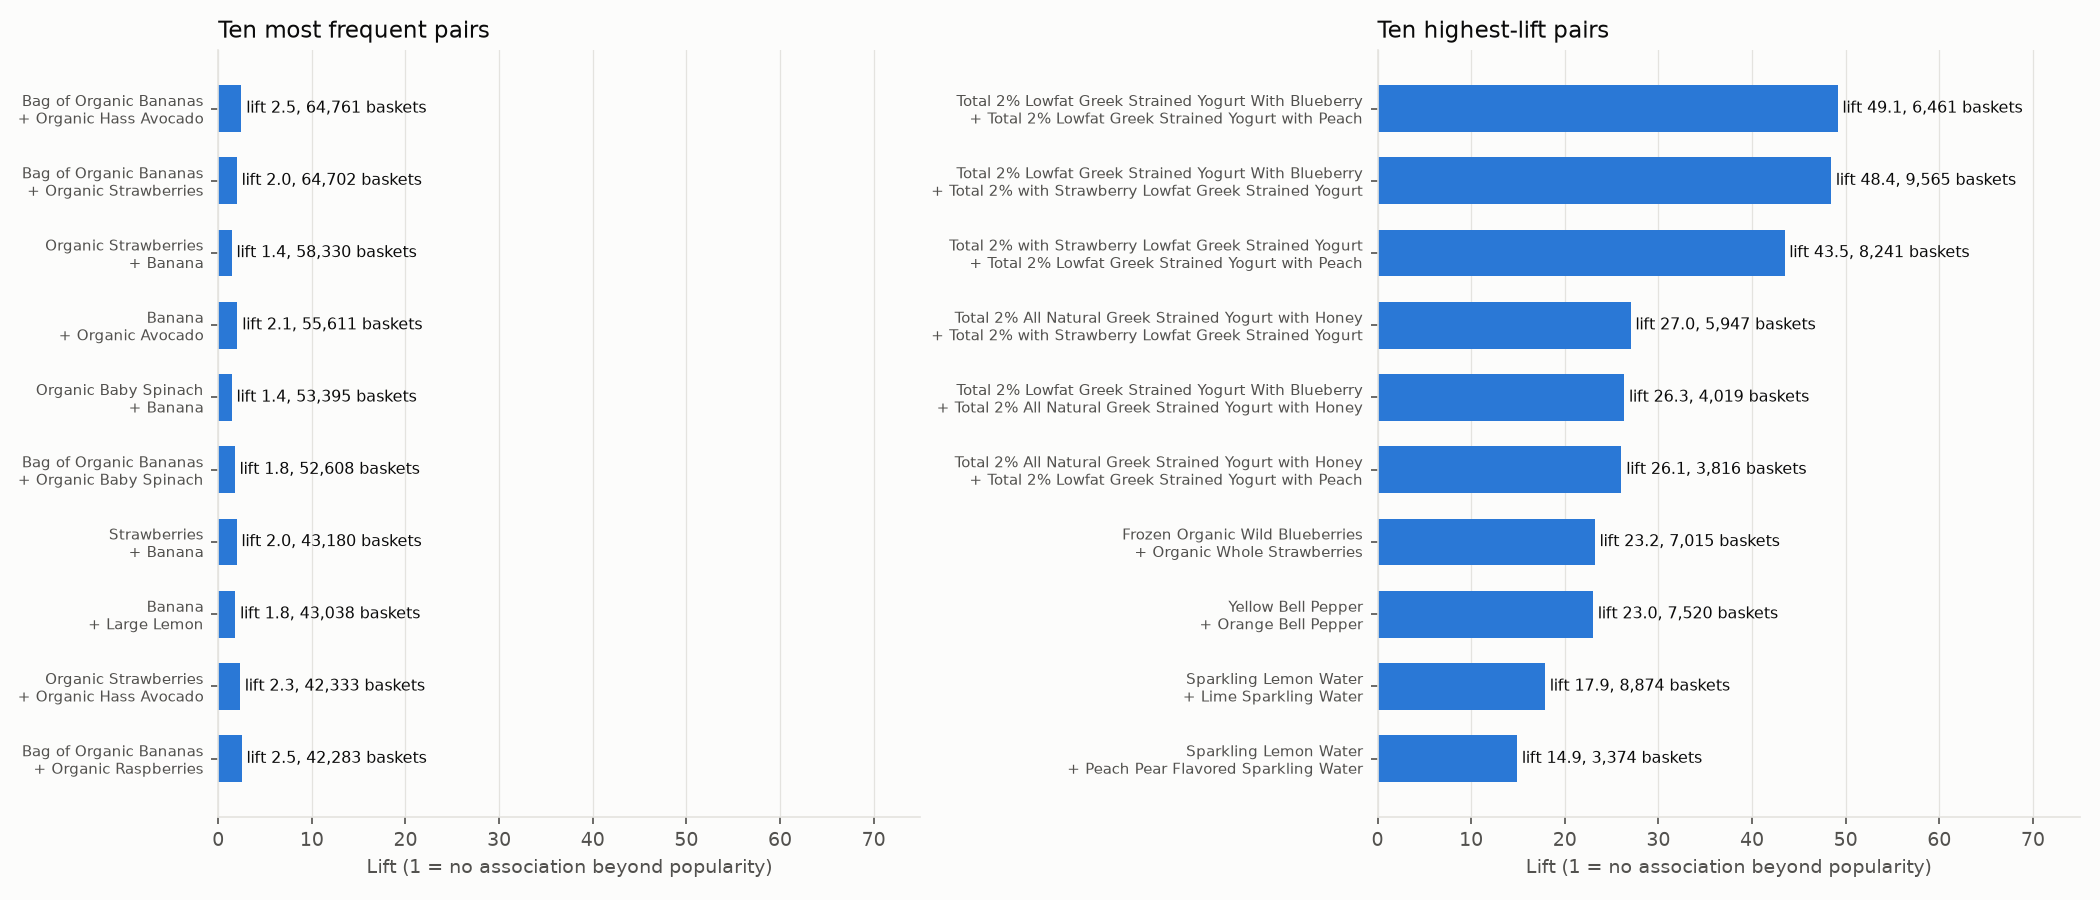

In [8]:
display(pd.read_csv(T / "affinity_top_by_count.csv").head(10)[["product_a_name", "product_b_name", "pair_orders", "lift"]])
display(pd.read_csv(T / "affinity_top_by_lift.csv").head(10)[["product_a_name", "product_b_name", "pair_orders", "lift"]])
Image(ROOT / "reports" / "affinity_count_vs_lift.png")

The most frequent pairs are bananas, avocados, strawberries and spinach. These co-occur mostly because each is in many baskets, and their lifts are between 1.4 and 2.5. The highest-lift pairs are flavors of the same Greek yogurt line (lift 43-49) and sparkling waters, which are close substitutes that tend to be bought in the same order. High lift here shows variety buying within a product line, which is not a basis for a cross-sell recommendation by itself.

## 6. Simulated A/B test

Nothing below is real experiment data. Control outcomes are real users' outcomes, treatment effects are injected, and the setup and decision rule are in `docs/ab_test_design.md`.

In [9]:
display(pd.read_csv(T / "ab_power_plan.csv").T)
display(pd.read_csv(T / "ab_demo_run.csv").T)
s = pd.read_csv(T / "ab_scenarios.csv").set_index("scenario")
display(s.T)

,0
baseline_rate,0.5575
alpha,0.0500
power,0.8000
mde_abs,0.0200
n_per_arm,9632.0000
n_total,19264.0000
available_users,206209.0000
mde_if_all_users_used,0.0061


,0
true_effect,0.0200
n_control,9537
n_treatment,9727
srm_p,0.1710
srm_flag,False
rate_control,0.5564
rate_treatment,0.5807
abs_lift,0.0243
abs_lift_ci_low,0.0103
abs_lift_ci_high,0.0383


scenario,effect_at_mde,aa_no_effect,effect_with_guardrail_harm,effect_with_srm_bug
n_sims,2000.0000,2000.0000,2000.0000,2000.0000
true_effect,0.0200,0.0000,0.0200,0.0200
guardrail_harm_items,0.0000,0.0000,1.0000,0.0000
srm_drop,0.0000,0.0000,0.0000,0.0500
primary_significant_rate,0.8010,0.0435,0.7835,0.7865
primary_significant_mc_se,0.0089,0.0046,0.0092,0.0092
mean_abs_lift_estimate,0.0199,0.0000,0.0200,0.0201
abs_lift_ci_coverage,0.9475,0.9565,0.9440,0.9480
guardrail_fail_rate,0.0205,0.0220,1.0000,0.0215
srm_flag_rate,0.0015,0.0005,0.0000,0.5880


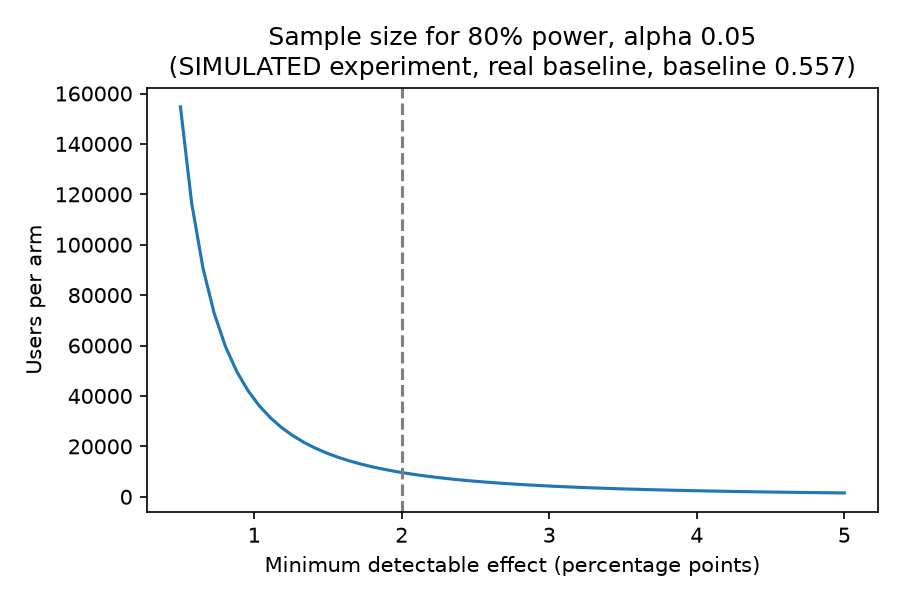

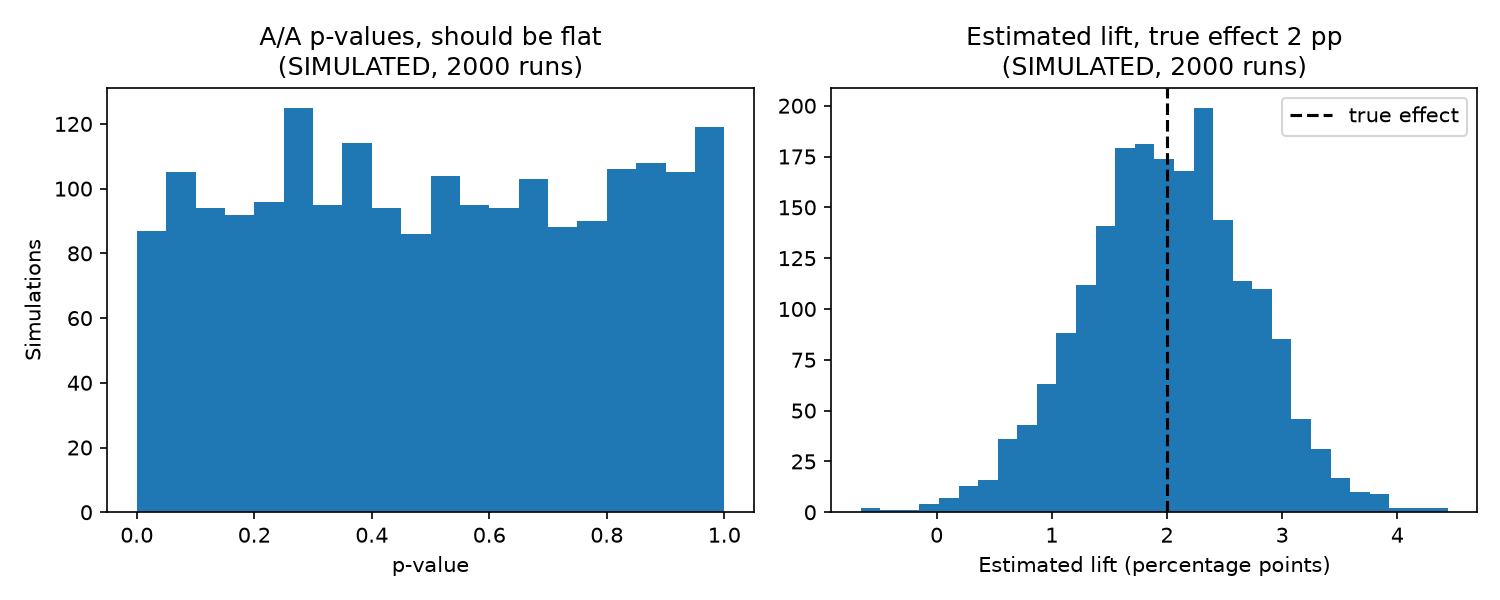

In [10]:
display(Image(ROOT / "reports" / "ab_sample_size.png"))
Image(ROOT / "reports" / "ab_simulation_checks.png")

With a baseline of 55.7% and a minimum detectable effect of 2 percentage points, each arm needs 9,632 users at 80% power. In 2,000 repeated runs with a true 2-point effect the test detected it 80.1% of the time, the average estimate was 1.99 points, and the 95% interval contained the true value in 94.8% of runs. In 2,000 A/A runs the false positive rate was 4.35% (Monte Carlo standard error 0.46 points). An injected 1-item drop in basket size was blocked by the guardrail in every run. A 5% loss of treated users was flagged by the sample ratio check in 58.8% of runs at the p < 0.001 threshold, so the check is not sensitive to a loss that small at this sample size.

This shows that the analysis code is correct when the truth is known. It does not show that a reminder would work.